# Palm Tree Detection — Faster R-CNN (TensorFlow + KerasCV + OpenCV)

Fokus pada **Faster R-CNN** (two-stage detector) dan memakai **OpenCV** untuk image I/O serta visualisasi inference. Pipeline data tetap berbasis `tf.data` + KerasCV. Disesuaikan untuk lingkungan Kaggle: input read-only di `/kaggle/input/`, working dir di `/kaggle/working/`, dan kompatibel dengan Keras 3 / Keras 2 legacy.

**Stack:**

- TensorFlow 2.x — training engine, `tf.data` pipeline
- KerasCV — Faster R-CNN model + augmentasi sadar bbox + COCO metrics
- OpenCV (`cv2`) — decode/encode JPG, draw rectangles & label saat inference


## 1. Import

In [ ]:
# 1. Setup

import os
import json
import random
import shutil
import sysconfig
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
import tensorflow as tf
import keras_cv


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


2026-06-06 14:37:13.411149: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-06 14:37:13.445966: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-06 14:37:13.578222: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-06 14:37:13.578253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-06 14:37:13.605135: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

Using TensorFlow backend


/home/kazu/Programming/OpenSource/model-nyawit/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


nv_path = os.path.join(sysconfig.get_paths()['purelib'], 'nvidia')
lib_paths = [os.path.join(root, d) for root, dirs, files in os.walk(nv_path) for d in dirs if d == 'lib']
if lib_paths:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(lib_paths) + ':' + os.environ.get('LD_LIBRARY_PATH', '')



gpus = tf.config.list_physical_devices("GPU")
print(f"GPU available: {len(gpus) > 0}")
for gpu in gpus:
    print(f"  - {gpu.name}")
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("  (memory growth not set)", e)


print(f"TensorFlow : {tf.__version__}")
print(f"KerasCV    : {keras_cv.__version__}")
print(f"OpenCV     : {cv2.__version__}")


GPU available: False
TensorFlow : 2.15.0
KerasCV    : 0.8.2
OpenCV     : 4.11.0


## 2. Dataset Preparation (COCO → record list)

- **Sumber**: `/kaggle/input/<slug>/` (read-only). Sesuaikan `SOURCE_ROOT` dengan slug dataset Anda.
- **Output**: `/kaggle/working/dataset/records.json` (path gambar tetap menunjuk ke `/kaggle/input` agar tidak boros disk 20 GB di working dir).

Format bbox di records: `xywh` piksel.


In [ ]:
BASE_DIR = Path("..").resolve()
SOURCE_ROOT = BASE_DIR / "datasets"
DATA_ROOT   = BASE_DIR / "working" / "dataset"  # Folder baru untuk menyimpan records.json

# Verifikasi folder dataset lokal
if not (SOURCE_ROOT / "annotations").exists():
    raise FileNotFoundError(
        f"Folder anotasi tidak ditemukan di {SOURCE_ROOT}/annotations. "
        "Pastikan struktur folder datasets sudah benar."
    )

def create_dataset_structure():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

def coco_to_records(coco_path, images_src):
    """Parse a COCO json into a list of records pointing langsung ke path lokal."""
    with open(coco_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    categories = sorted(coco["categories"], key=lambda c: c["id"])
    cat_id_to_idx = {c["id"]: i for i, c in enumerate(categories)}
    names = [c["name"] for c in categories]

    images = {img["id"]: img for img in coco["images"]}
    by_image = defaultdict(list)

    for ann in coco["annotations"]:
        if ann.get("iscrowd", 0):
            continue
        x, y, w, h = ann["bbox"]
        if w <= 0 or h <= 0:
            continue
        cls = cat_id_to_idx.get(ann["category_id"])
        if cls is None:
            continue
        by_image[ann["image_id"]].append([cls, float(x), float(y), float(w), float(h)])

    records = []
    for img_id, img in images.items():
        boxes = by_image.get(img_id, [])
        if not boxes:
            continue
        src = Path(images_src) / img["file_name"]
        if not src.exists():
            continue
        records.append({
            "image_path": str(src),  # path absolut lokal
            "width":  int(img["width"]),
            "height": int(img["height"]),
            "boxes":  boxes,
        })
    return records, names

def split_records(records, ratios=(0.5, 0.5), seed=SEED):
    rng = random.Random(seed)
    items = records[:]
    rng.shuffle(items)
    n_a = int(len(items) * ratios[0])
    return items[:n_a], items[n_a:]

def ensure_dataset(force=False):
    create_dataset_structure()
    records_path = DATA_ROOT / "records.json"

    if records_path.exists() and not force:
        with open(records_path, "r", encoding="utf-8") as f:
            payload = json.load(f)
        print(
            f"Loaded cached records: train={len(payload['train'])} "
            f"val={len(payload['val'])} test={len(payload['test'])}"
        )
        return payload

    coco_train = SOURCE_ROOT / "annotations/instances_train2017.json"
    coco_val   = SOURCE_ROOT / "annotations/instances_val2017.json"

    train_records, names_train = coco_to_records(coco_train, SOURCE_ROOT / "train2017")
    val_full,      names_val   = coco_to_records(coco_val,   SOURCE_ROOT / "val2017")

    # Split val_full menjadi val/test 50/50 
    val_records, test_records = split_records(val_full, ratios=(0.5, 0.5))

    names = names_train or names_val or CLASS_NAMES
    payload = {
        "train": train_records,
        "val":   val_records,
        "test":  test_records,
        "names": names,
    }
    with open(records_path, "w", encoding="utf-8") as f:
        json.dump(payload, f)

    print(
        f"Prepared records: train={len(train_records)} "
        f"val={len(val_records)} test={len(test_records)}"
    )
    print(f"Class names: {names}")
    return payload

DATASET = ensure_dataset()
CLASS_NAMES = DATASET["names"] or CLASS_NAMES
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Prepared records: train=1803 val=250 test=250
Class names: ['Dead', 'Healthy', 'Grass', 'Small', 'Yellow']
Classes (5): ['Dead', 'Healthy', 'Grass', 'Small', 'Yellow']


### 2b. Visualisasi sampel dengan OpenCV

Berbeda dengan notebook RetinaNet, di sini kita memakai `cv2.rectangle` + `cv2.putText` untuk menggambar bounding box dan menyimpan thumbnail ke `/kaggle/working/dataset/preview/`.


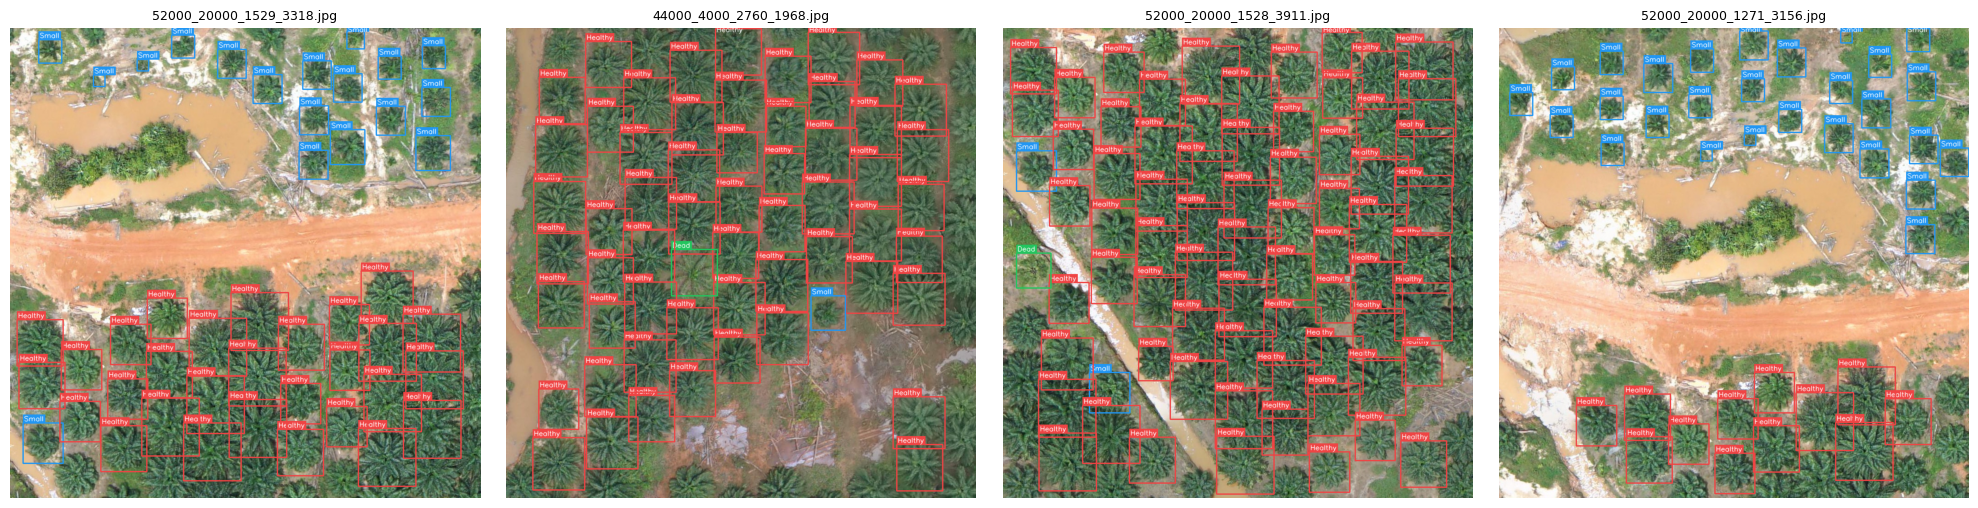

Preview thumbnails saved to: /home/kazu/Programming/OpenSource/model-nyawit/working/dataset/preview


In [ ]:
# 2b. Visualisasi sampel pakai OpenCV
PREVIEW_DIR = DATA_ROOT / "preview"
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

# Palet warna BGR (OpenCV memakai BGR)
BGR_PALETTE = [
    (94, 197, 34),    # Healthy-ish
    (68, 68, 239),    # red-ish
    (203, 192, 255),  # pink
    (243, 150, 33),   # orange
    (0, 255, 255),    # yellow
    (255, 191, 0),    # cyan-blue
    (180, 105, 255),  # magenta
]


def draw_boxes_cv2(img_bgr, boxes_xywh_cls, classes=None, thickness=2):
    """img_bgr: HxWx3 BGR uint8. boxes_xywh_cls: list of [cls, x, y, w, h]."""
    classes = classes or CLASS_NAMES
    out = img_bgr.copy()
    for cls, x, y, w, h in boxes_xywh_cls:
        cls = int(cls)
        color = BGR_PALETTE[cls % len(BGR_PALETTE)]
        x1, y1, x2, y2 = int(x), int(y), int(x + w), int(y + h)
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        label = classes[cls] if cls < len(classes) else str(cls)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, max(0, y1 - th - 6)), (x1 + tw + 4, y1), color, -1)
        cv2.putText(
            out, label, (x1 + 2, max(th, y1) - 4),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA,
        )
    return out


def visualize_records_cv2(records, n=4, classes=None, save=True):
    samples = records[:n]
    if not samples:
        print("No records to visualize.")
        return
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]
    for ax, rec in zip(axes, samples):
        img_bgr = cv2.imread(rec["image_path"])  # OpenCV decode
        if img_bgr is None:
            ax.set_title("failed to load"); ax.axis("off"); continue
        annotated_bgr = draw_boxes_cv2(img_bgr, rec["boxes"], classes=classes)
        if save:
            out_path = PREVIEW_DIR / Path(rec["image_path"]).name
            cv2.imwrite(str(out_path), annotated_bgr)
        ax.imshow(cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB))
        ax.axis("off")
        ax.set_title(Path(rec["image_path"]).name, fontsize=9)
    plt.tight_layout()
    plt.show()


visualize_records_cv2(DATASET["train"], n=4)
print(f"Preview thumbnails saved to: {PREVIEW_DIR}")



## 3. Augmentasi & `tf.data` pipeline

Decoding gambar dilakukan via OpenCV di Python (lewat `tf.numpy_function`) supaya konsisten dengan tooling visualisasi. Augmentasi tetap pakai layer KerasCV yang sadar bbox.

`BATCH_SIZE = 2` untuk Faster R-CNN — model ini VRAM-hungry karena RPN + ROI head. Bisa coba 4 di P100 16 GB jika resolusi diturunkan.


In [6]:
# 3. Data Augmentation & tf.data pipeline
IMG_SIZE    = 1024
BATCH_SIZE  = 2     # Faster R-CNN: VRAM-hungry, batch kecil
BBOX_FORMAT = "xywh"


def record_generator(records):
    for rec in records:
        if not rec["boxes"]:
            classes = np.zeros((0,), dtype=np.int32)
            xywh    = np.zeros((0, 4), dtype=np.float32)
        else:
            arr = np.asarray(rec["boxes"], dtype=np.float32)
            classes = arr[:, 0].astype(np.int32)
            xywh    = arr[:, 1:].astype(np.float32)
        yield {
            "image_path": rec["image_path"],
            "classes":    classes,
            "boxes":      xywh,
        }


def _cv2_decode(path_bytes):
    """Decode JPG/PNG dengan OpenCV, kembalikan RGB uint8 HxWx3."""
    path = path_bytes.decode("utf-8") if isinstance(path_bytes, bytes) else path_bytes
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"cv2.imread failed: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb.astype(np.uint8)


def load_image(sample):
    img = tf.numpy_function(_cv2_decode, [sample["image_path"]], tf.uint8)
    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)
    return {
        "images": img,
        "bounding_boxes": {
            "classes": sample["classes"],
            "boxes":   sample["boxes"],
        },
    }


def make_dataset(records, training, batch_size=BATCH_SIZE):
    output_signature = {
        "image_path": tf.TensorSpec((),       tf.string),
        "classes":    tf.TensorSpec((None,),  tf.int32),
        "boxes":      tf.TensorSpec((None, 4), tf.float32),
    }
    ds = tf.data.Dataset.from_generator(
        lambda: record_generator(records),
        output_signature=output_signature,
    )
    if training:
        ds = ds.shuffle(min(len(records), 512), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        augmenter = keras_cv.layers.Augmenter([
            keras_cv.layers.RandomFlip(
                mode="horizontal", bounding_box_format=BBOX_FORMAT,
            ),
            keras_cv.layers.JitteredResize(
                target_size=(IMG_SIZE, IMG_SIZE),
                scale_factor=(0.85, 1.15),
                bounding_box_format=BBOX_FORMAT,
            ),
        ])
        ds = ds.map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        resizer = keras_cv.layers.Resizing(
            IMG_SIZE, IMG_SIZE,
            pad_to_aspect_ratio=True,
            bounding_box_format=BBOX_FORMAT,
        )
        ds = ds.map(resizer, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.ragged_batch(batch_size, drop_remainder=training)
    return ds.prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(DATASET["train"], training=True)
val_ds   = make_dataset(DATASET["val"],   training=False)
test_ds  = make_dataset(DATASET["test"],  training=False)

print("Datasets ready (OpenCV decoder).")
print(f"  train batches ≈ {max(1, len(DATASET['train']) // BATCH_SIZE)}")
print(f"  val batches   ≈ {max(1, len(DATASET['val'])   // BATCH_SIZE)}")
print(f"  test batches  ≈ {max(1, len(DATASET['test'])  // BATCH_SIZE)}")



Datasets ready (OpenCV decoder).
  train batches ≈ 901
  val batches   ≈ 125
  test batches  ≈ 125


## 4. Faster R-CNN Training

KerasCV `FasterRCNN` dengan backbone ResNet50 ImageNet. Loss: RPN (BCE + Huber) + ROI head (CategoricalCrossentropy + Huber).

LR schedule `PiecewiseConstantDecay` (drop 10× di 60% dan 85% epoch) — pola standar untuk Faster R-CNN. Semua artefak training disimpan ke `/kaggle/working/runs/...` agar persistent setelah session berakhir.


In [8]:
# 4. Faster R-CNN Training
FRCNN_EPOCHS = 150
FRCNN_LR     = 0.001

BASE_DIR = Path("..").resolve()
WORK_ROOT = BASE_DIR / "working"


def dict_to_tuple(inputs):
    return inputs["images"], inputs["bounding_boxes"]

train_tuples = train_ds.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
val_tuples   = val_ds.map(dict_to_tuple,   num_parallel_calls=tf.data.AUTOTUNE)

FasterRCNN = getattr(keras_cv.models, "FasterRCNN", None)
use_frcnn = FasterRCNN is not None
if not use_frcnn:
    print("FasterRCNN not available in this KerasCV build; falling back to RetinaNet.")

exp_name = "fasterrcnn_exp1" if use_frcnn else "retinanet_fallback_exp1"
ckpt_dir  = Path("..").resolve() / "models" / f"{exp_name}"
ckpt_dir.mkdir(parents=True, exist_ok=True) # Sekarang akan sukses membuat folder di dalam /working
best_weights_path = ckpt_dir / "best.weights.h5"

if use_frcnn:
    backbone = keras_cv.models.ResNet50Backbone.from_preset("resnet50_imagenet")
    frcnn = FasterRCNN(
        num_classes=NUM_CLASSES,
        bounding_box_format=BBOX_FORMAT,
        backbone=backbone,
    )
else:
    frcnn = keras_cv.models.RetinaNet.from_preset(
        "resnet50_imagenet",
        num_classes=NUM_CLASSES,
        bounding_box_format=BBOX_FORMAT,
    )

frcnn.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format=BBOX_FORMAT,
    from_logits=True,
    iou_threshold=0.5,
    confidence_threshold=0.5,
 )

steps_per_epoch = max(1, len(DATASET["train"]) // BATCH_SIZE)
if use_frcnn:
    lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
        boundaries=[
            int(FRCNN_EPOCHS * 0.6  * steps_per_epoch),
            int(FRCNN_EPOCHS * 0.85 * steps_per_epoch),
        ],
        values=[FRCNN_LR, FRCNN_LR * 0.1, FRCNN_LR * 0.01],
    )
else:
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        FRCNN_LR, FRCNN_EPOCHS * steps_per_epoch
    )
optimizer = tf.keras.optimizers.SGD(
    learning_rate=lr_schedule, momentum=0.9, global_clipnorm=10.0,
 )

if use_frcnn:
    frcnn.compile(
        optimizer=optimizer,
        box_loss=tf.keras.losses.Huber(reduction="sum"),
        classification_loss=tf.keras.losses.CategoricalCrossentropy(
            from_logits=True, reduction="sum",
        ),
        rpn_box_loss=tf.keras.losses.Huber(reduction="sum"),
        rpn_classification_loss=tf.keras.losses.BinaryCrossentropy(
            from_logits=True, reduction="sum",
        ),
        jit_compile=False,
    )
else:
    frcnn.compile(
        classification_loss="focal",
        box_loss="smoothl1",
        optimizer=optimizer,
        jit_compile=False,
    )

# Resume otomatis bila checkpoint sebelumnya tersedia
if best_weights_path.exists():
    try:
        frcnn.load_weights(str(best_weights_path))
        print(f"Resumed weights from {best_weights_path}")
    except Exception as e:
        print(f"Could not resume from checkpoint ({e}); training from scratch.")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_weights_path),
        save_weights_only=True,
        monitor="val_loss", mode="min", save_best_only=True, verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8,
        restore_best_weights=True, verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(ckpt_dir / "training_log.csv")),
    tf.keras.callbacks.TerminateOnNaN(),
]

history = frcnn.fit(
    train_tuples,
    validation_data=val_tuples,
    epochs=FRCNN_EPOCHS,
    callbacks=callbacks,
 )

# Plot kurva loss
hist = history.history
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist.get("loss", []),     label="train loss")
if "val_loss" in hist:
    ax.plot(hist["val_loss"], label="val loss")
title = "Faster R-CNN" if use_frcnn else "RetinaNet"
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(f"{title} Training Loss")
ax.legend()
plt.tight_layout()
plt.savefig(ckpt_dir / "loss_curve.png", dpi=120)
plt.show()

FasterRCNN not available in this KerasCV build; falling back to RetinaNet.


100%|██████████| 777/777 [00:00<00:00, 5.84kB/s]


100%|██████████| 90.3M/90.3M [08:27<00:00, 187kB/s]
/home/kazu/Programming/OpenSource/model-nyawit/.venv/lib/python3.11/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/home/kazu/Programming/OpenSource/model-nyawit/.venv/lib/python3.11/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `layer.updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids


Epoch 1/150
     27/Unknown - 80s 3s/step - loss: 1.6499 - box_loss: 0.6988 - classification_loss: 0.9511 - percent_boxes_matched_with_anchor: 0.1696

KeyboardInterrupt: 

## 5. Evaluation

Dua metrik:

1. **COCO mAP** via `keras_cv.metrics.BoxCOCOMetrics` (mAP@0.5, mAP@0.5:0.95, recall, dll).
2. **Confusion matrix** sederhana berbasis distribusi kelas (frequency-only, sama seperti notebook YOLO asli).


In [9]:
# 5a. COCO mAP
# Materialize test batches first to avoid double-iteration bug
_test_batches = list(test_ds)
print(f"Test batches: {len(_test_batches)}")

def compute_max_boxes_from_batches(batches):
    max_boxes = 0
    for batch in batches:
        boxes = batch["bounding_boxes"]["boxes"]
        if isinstance(boxes, tf.RaggedTensor):
            batch_max = tf.reduce_max(boxes.row_lengths(axis=1)).numpy()
        else:
            batch_max = boxes.shape[1] or int(tf.shape(boxes)[1].numpy())
        max_boxes = max(max_boxes, int(batch_max))
    return max_boxes

MAX_BOXES = max(1, compute_max_boxes_from_batches(_test_batches))
print(f"MAX_BOXES for COCO metric: {MAX_BOXES}")

def ensure_dense(boxes):
    if isinstance(boxes["boxes"], tf.RaggedTensor):
        return keras_cv.bounding_box.to_dense(boxes, max_boxes=MAX_BOXES)

    dense = {
        "boxes": boxes["boxes"],
        "classes": boxes["classes"],
    }
    if "confidence" in boxes:
        dense["confidence"] = boxes["confidence"]

    cur = dense["boxes"].shape[1]
    if cur is None:
        cur = int(tf.shape(dense["boxes"])[1].numpy())

    if cur < MAX_BOXES:
        pad = MAX_BOXES - cur
        dense["boxes"] = tf.pad(dense["boxes"], [[0, 0], [0, pad], [0, 0]], constant_values=-1.0)
        dense["classes"] = tf.pad(dense["classes"], [[0, 0], [0, pad]], constant_values=-1)
        if "confidence" in dense:
            dense["confidence"] = tf.pad(dense["confidence"], [[0, 0], [0, pad]], constant_values=0.0)
    elif cur > MAX_BOXES:
        dense["boxes"] = dense["boxes"][:, :MAX_BOXES, :]
        dense["classes"] = dense["classes"][:, :MAX_BOXES]
        if "confidence" in dense:
            dense["confidence"] = dense["confidence"][:, :MAX_BOXES]

    return dense

coco_metric = keras_cv.metrics.BoxCOCOMetrics(
    bounding_box_format=BBOX_FORMAT, evaluate_freq=10**9,
 )
coco_metric.reset_state()
for batch in _test_batches:
    y_pred = frcnn.predict(batch["images"], verbose=0)
    gt_dense = ensure_dense(batch["bounding_boxes"])
    pred_dense = ensure_dense(y_pred)
    coco_metric.update_state(gt_dense, pred_dense)
results = coco_metric.result(force=True)
for k, v in results.items():
    print(f"{k:35s}: {float(v):.4f}")

# Persist metrics ke working dir
with open(ckpt_dir / "coco_metrics.json", "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in results.items()}, f, indent=2)


# 5b. Confusion matrix (frequency-based)
model_name = "Faster R-CNN" if "use_frcnn" in globals() and use_frcnn else "RetinaNet"

y_true_cls, y_pred_cls = [], []
for batch in _test_batches:
    tc = batch["bounding_boxes"]["classes"]
    if hasattr(tc, "flat_values"): tc = tc.flat_values
    y_true_cls.extend(np.asarray(tc).reshape(-1).tolist())
    preds = frcnn.predict(batch["images"], verbose=0)
    pc = preds["classes"]
    if hasattr(pc, "flat_values"): pc = pc.flat_values
    y_pred_cls.extend(np.asarray(pc).reshape(-1).tolist())

y_true_cls = [int(c) for c in y_true_cls if c >= 0]
y_pred_cls = [int(c) for c in y_pred_cls if c >= 0]
trim = min(len(y_true_cls), len(y_pred_cls))
labels = list(range(NUM_CLASSES))
cm = confusion_matrix(y_true_cls[:trim], y_pred_cls[:trim], labels=labels)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Confusion Matrix \u2014 {model_name}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(ckpt_dir / "confusion_matrix.png", dpi=120)
plt.show()
print(classification_report(
    y_true_cls[:trim], y_pred_cls[:trim],
    labels=labels, target_names=CLASS_NAMES, zero_division=0,
))

MAX_BOXES for COCO metric: 85


KeyboardInterrupt: 

## 6. Inference & Counting (OpenCV renderer)

Versi inference ini menggunakan OpenCV penuh: `cv2.imread` untuk load, `cv2.rectangle` + `cv2.putText` untuk anotasi, `cv2.imwrite` untuk save. Output ditulis ke `/kaggle/working/output/` agar bisa diunduh setelah commit.


In [ ]:
# 6. Inference & Counting via OpenCV
OUTPUT_DIR = WORK_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def detect_and_count(image_path, model, conf=0.5, save_path=None, classes=None,
                    show=True):
    classes = classes or CLASS_NAMES

    # 1) Load dengan OpenCV (BGR)
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(image_path)
    orig_h, orig_w = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2) Resize + pad ke IMG_SIZE
    resizer = keras_cv.layers.Resizing(
        IMG_SIZE, IMG_SIZE, pad_to_aspect_ratio=True, bounding_box_format=BBOX_FORMAT,
    )
    inputs = {
        "images": tf.cast(img_rgb, tf.float32)[tf.newaxis, ...],
        "bounding_boxes": {
            "classes": tf.zeros((1, 0), tf.int32),
            "boxes":   tf.zeros((1, 0, 4), tf.float32),
        },
    }
    inputs = resizer(inputs)
    preds = model.predict(inputs["images"], verbose=0)

    boxes_xywh = np.asarray(preds["boxes"][0],      dtype=np.float32)
    pred_cls   = np.asarray(preds["classes"][0],    dtype=np.int32)
    pred_conf  = np.asarray(preds["confidence"][0], dtype=np.float32)

    keep = (pred_cls >= 0) & (pred_conf >= conf)
    boxes_xywh, pred_cls, pred_conf = boxes_xywh[keep], pred_cls[keep], pred_conf[keep]

    # 3) Reverse-map ke koordinat gambar asli
    scale = min(IMG_SIZE / orig_w, IMG_SIZE / orig_h)
    pad_x = (IMG_SIZE - orig_w * scale) / 2
    pad_y = (IMG_SIZE - orig_h * scale) / 2
    if len(boxes_xywh) > 0:
        boxes_xywh[:, 0] = (boxes_xywh[:, 0] - pad_x) / scale
        boxes_xywh[:, 1] = (boxes_xywh[:, 1] - pad_y) / scale
        boxes_xywh[:, 2] = boxes_xywh[:, 2] / scale
        boxes_xywh[:, 3] = boxes_xywh[:, 3] / scale

    # 4) Render dengan OpenCV
    counts = defaultdict(int)
    annotated = img_bgr.copy()
    for (x, y, w, h), cls, score in zip(boxes_xywh, pred_cls, pred_conf):
        cls = int(cls); counts[cls] += 1
        color = BGR_PALETTE[cls % len(BGR_PALETTE)]
        x1, y1, x2, y2 = int(x), int(y), int(x + w), int(y + h)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        label = f"{classes[cls] if cls < len(classes) else cls} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (x1, max(0, y1 - th - 6)), (x1 + tw + 4, y1), color, -1)
        cv2.putText(
            annotated, label, (x1 + 2, max(th, y1) - 4),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA,
        )

    # Counter overlay (kiri-atas)
    y0 = 25
    for cls in sorted(counts.keys()):
        color = BGR_PALETTE[cls % len(BGR_PALETTE)]
        text = f"{classes[cls] if cls < len(classes) else cls}: {counts[cls]}"
        cv2.putText(annotated, text, (10, y0),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
        y0 += 24

    # 5) Save / show
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(save_path), annotated)

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return dict(counts)


# Auto-demo: jalankan pada beberapa gambar test pertama
for i, rec in enumerate(DATASET["test"][:3]):
    out_path = OUTPUT_DIR / f"detected_frcnn_{i}.jpg"
    counts = detect_and_count(rec["image_path"], frcnn, save_path=out_path)
    print(f"[{i}] {rec['image_path']} → counts: {counts}")



## 7. Export Model

- **SavedModel** — format native TensorFlow (via `model.export()`, kompatibel Keras 3 dan Keras 2).
- **TFLite** — untuk deployment edge / mobile.
- **ONNX** — opsional via `tf2onnx`.

Semua output diletakkan di `/kaggle/working/runs/.../exported/` agar bisa diunduh sebagai output notebook setelah commit. Bobot terbaik berada di `best.weights.h5`.


In [ ]:
# 7. Export Model
export_dir = ckpt_dir / "exported"
export_dir.mkdir(parents=True, exist_ok=True)
savedmodel_path = export_dir / "saved_model"

# SavedModel: pakai model.export() bila tersedia (Keras 3), fallback ke model.save()
saved_ok = False
try:
    if hasattr(frcnn, "export"):
        frcnn.export(str(savedmodel_path))
    else:
        frcnn.save(str(savedmodel_path), save_format="tf")
    saved_ok = savedmodel_path.exists()
    print(f"SavedModel: {savedmodel_path}")
except Exception as e:
    print(f"SavedModel export failed ({e}); falling back to weights only.")
    frcnn.save_weights(str(export_dir / "best.weights.h5"))

# TFLite
try:
    if saved_ok:
        converter = tf.lite.TFLiteConverter.from_saved_model(str(savedmodel_path))
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite_path = export_dir / "best.tflite"
        tflite_path.write_bytes(converter.convert())
        print(f"TFLite    : {tflite_path}")
    else:
        print("TFLite skipped (SavedModel unavailable).")
except Exception as e:
    print(f"TFLite export skipped: {e}")

# ONNX (opsional)
try:
    import tf2onnx  # noqa: F401
    if saved_ok:
        onnx_path = export_dir / "best.onnx"
        rc = os.system(
            f'python -m tf2onnx.convert --saved-model "{savedmodel_path}" '
            f'--output "{onnx_path}" --opset 17'
        )
        if rc == 0 and onnx_path.exists():
            print(f"ONNX      : {onnx_path}")
        else:
            print("ONNX export returned non-zero status; check log above.")
    else:
        print("ONNX skipped (SavedModel unavailable).")
except ImportError:
    print("tf2onnx not installed; skipping ONNX export.")

print("\nAll artifacts under:", export_dir)
for p in sorted(export_dir.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / (1024 * 1024)
        print(f"  {p.relative_to(export_dir)}  ({size_mb:.1f} MB)")